In [79]:
import pandas as pd
import numpy as np

## 1. Load the file and Study the Dataset


In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
df = pd.read_csv("/content/drive/MyDrive/DES SEM III/HDS/HDS_Project/brca_metabric_clinical_data.tsv", sep="\t")
df.head()

,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,...,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,...,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,...,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,...,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease
3,brca_metabric,MB-0006,MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,...,164.933333,0:Not Recurred,1,Primary,Female,NaN,1.307518,25.0,2.0,Living
4,brca_metabric,MB-0008,MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,...,18.800000,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0,Died of Disease


In [82]:
columns_to_drop = [
    "Patient's Vital Status",
    "Hormone Therapy",
    "Radio Therapy",
    "Cohort",
    "Number of Samples Per Patient"
]

df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])

In [83]:
print("Shape:", df.shape)
print("\nColumns:")
for i, c in enumerate(df.columns):
    print(f"{i+1:02d}. {c}",)

Shape: (2509, 34)

Columns:
01. Study ID
02. Patient ID
03. Sample ID
04. Age at Diagnosis
05. Type of Breast Surgery
06. Cancer Type
07. Cancer Type Detailed
08. Cellularity
09. Chemotherapy
10. Pam50 + Claudin-low subtype
11. ER status measured by IHC
12. ER Status
13. Neoplasm Histologic Grade
14. HER2 status measured by SNP6
15. HER2 Status
16. Tumor Other Histologic Subtype
17. Inferred Menopausal State
18. Integrative Cluster
19. Primary Tumor Laterality
20. Lymph nodes examined positive
21. Mutation Count
22. Nottingham prognostic index
23. Oncotree Code
24. Overall Survival (Months)
25. Overall Survival Status
26. PR Status
27. Relapse Free Status (Months)
28. Relapse Free Status
29. Sample Type
30. Sex
31. 3-Gene classifier subtype
32. TMB (nonsynonymous)
33. Tumor Size
34. Tumor Stage


In [84]:
print("\n Missing values")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(40))


 Missing values


,0
3-Gene classifier subtype,745
Tumor Stage,721
Primary Tumor Laterality,639
Cellularity,592
Type of Breast Surgery,554
Inferred Menopausal State,529
PR Status,529
HER2 Status,529
Chemotherapy,529
Pam50 + Claudin-low subtype,529


In [85]:
# 2) Robust cleaning module (master)
import re

df_clean = df.copy()

def to_num(x):
    try:
        if pd.isna(x):
            return np.nan
        s = str(x).strip().replace(",", "")
        if s.lower() in ["none", "na", "nan", "", "-", "--", "null"]:
            return np.nan
        return float(s)
    except:
        return np.nan

def extract_status_digit(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    m = re.search(r'\b([01])\b', s)
    if m:
        return int(m.group(1))
    try:
        return int(float(s))
    except:
        return np.nan

def clean_yes_no(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapping = {
        "yes": 1, "y": 1, "1": 1, "true": 1, "t": 1,
        "no": 0, "n": 0, "0": 0, "false": 0, "f": 0
    }
    if s in mapping:
        return mapping[s]
    if "yes" in s:
        return 1
    if "no" in s:
        return 0
    return np.nan

# Apply cleaning for key columns
if "Overall Survival Status" in df_clean.columns:
    df_clean["Overall Survival Status"] = df_clean["Overall Survival Status"].apply(extract_status_digit)
if "Relapse Free Status" in df_clean.columns:
    df_clean["Relapse Free Status"] = df_clean["Relapse Free Status"].apply(extract_status_digit)
if "Chemotherapy" in df_clean.columns:
    df_clean["Chemotherapy"] = df_clean["Chemotherapy"].apply(clean_yes_no)

numeric_cols_to_clean = [
    "Overall Survival (Months)",
    "Relapse Free Status (Months)",
    "Tumor Size",
    "Tumor Stage",
    "Age at Diagnosis",
    "Mutation Count",
    "TMB (nonsynonymous)",
    "Lymph nodes examined positive",
    "Nottingham prognostic index"
]
for col in numeric_cols_to_clean:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(to_num)
        print(f"{col}: cleaned, missing = {df_clean[col].isna().sum()}")

# Normalize object/string categorical columns (strip etc.)
for col in df_clean.select_dtypes(include=["object"]).columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .replace("None", "", regex=False)
        .replace("nan", "", regex=False)
    )

print("\nCleaning summary (sample):")
display(df_clean[["Overall Survival (Months)","Overall Survival Status","Relapse Free Status","Chemotherapy"]].head(5))


Overall Survival (Months): cleaned, missing = 528
Relapse Free Status (Months): cleaned, missing = 121
Tumor Size: cleaned, missing = 149
Tumor Stage: cleaned, missing = 721
Age at Diagnosis: cleaned, missing = 11
Mutation Count: cleaned, missing = 151
TMB (nonsynonymous): cleaned, missing = 0
Lymph nodes examined positive: cleaned, missing = 266
Nottingham prognostic index: cleaned, missing = 222

Cleaning summary (sample):


,Overall Survival (Months),Overall Survival Status,Relapse Free Status,Chemotherapy
0,140.500000,0.0,0.0,0.0
1,84.633333,0.0,0.0,0.0
2,163.700000,1.0,1.0,1.0
3,164.933333,0.0,0.0,1.0
4,41.366667,1.0,1.0,1.0


In [86]:
# 3) Create Chemo_Response label (survival-based) and keep only chemo-treated rows
df_clean["Chemo_Response"] = np.nan

cond_chemo = df_clean.get("Chemotherapy") == 1
cond_os60 = df_clean.get("Overall Survival (Months)") > 60
cond_no_relapse = df_clean.get("Relapse Free Status") == 0

# Assign labels
df_clean.loc[cond_chemo & cond_os60 & cond_no_relapse, "Chemo_Response"] = 1
df_clean.loc[cond_chemo & (~(cond_os60 & cond_no_relapse)), "Chemo_Response"] = 0

# Keep only chemo-treated patients
before = df_clean.shape[0]
df_chemo = df_clean[df_clean["Chemo_Response"].notna()].copy()
after = df_chemo.shape[0]
print(f"Kept chemo-treated patients: {after} (dropped {before-after})")
print("\nChemo_Response counts:")
display(df_chemo["Chemo_Response"].value_counts(dropna=False))


Kept chemo-treated patients: 412 (dropped 2097)

Chemo_Response counts:


,count
Chemo_Response,
0.0,239
1.0,173


In [87]:
# 4) Drop leakage columns (these were used to create label; drop before modeling)
cols_to_drop = [
    "Overall Survival (Months)",
    "Overall Survival Status",
    "Relapse Free Status (Months)",
    "Relapse Free Status",
    "Patient's Vital Status",
    "Hormone Therapy",
    "Radio Therapy",
    "Chemotherapy",
    "Cohort",
    "Number of Samples Per Patient"
]
cols_existing = [c for c in cols_to_drop if c in df_chemo.columns]
print("Dropping:", cols_existing)
df_model = df_chemo.drop(columns=cols_existing)
print("Shape after drop:", df_model.shape)


Dropping: ['Overall Survival (Months)', 'Overall Survival Status', 'Relapse Free Status (Months)', 'Relapse Free Status', 'Chemotherapy']
Shape after drop: (412, 30)


In [88]:
# 5) Conservative list of baseline features to use
keep_manual = [
    "Age at Diagnosis",
    "Tumor Size",
    "Tumor Stage",
    "Neoplasm Histologic Grade",
    "Lymph nodes examined positive",
    "Nottingham prognostic index",
    "Mutation Count",
    "TMB (nonsynonymous)",
    "Type of Breast Surgery",
    "Cancer Type Detailed",
    "Cellularity",
    "Pam50 + Claudin-low subtype",
    "ER status measured by IHC",
    "ER Status",
    "PR Status",
    "HER2 status measured by SNP6",
    "HER2 Status",
    "Tumor Other Histologic Subtype",
    "Inferred Menopausal State",
    "Integrative Cluster",
    "Primary Tumor Laterality",
    "Oncotree Code",
    "Sample Type",
    "Sex",
    "3-Gene classifier subtype"
]
# Filter to available columns
keep_cols = [c for c in keep_manual if c in df_model.columns]
keep_cols = keep_cols + ["Chemo_Response"]
df_model = df_model[keep_cols].copy()
print("Columns used for modeling:", len(df_model.columns))
display(df_model.dtypes)


Columns used for modeling: 26


,0
Age at Diagnosis,float64
Tumor Size,float64
Tumor Stage,float64
Neoplasm Histologic Grade,float64
Lymph nodes examined positive,float64
Nottingham prognostic index,float64
Mutation Count,float64
TMB (nonsynonymous),float64
Type of Breast Surgery,object
Cancer Type Detailed,object


In [89]:
# 6) Imputation
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()

# remove target from numeric_cols if present
numeric_cols = [c for c in numeric_cols if c != "Chemo_Response"]

for col in numeric_cols:
    med = df_model[col].median()
    df_model[col].fillna(med, inplace=True)

for col in categorical_cols:
    mode = df_model[col].mode(dropna=True)
    if not mode.empty:
        df_model[col].fillna(mode[0], inplace=True)
    else:
        df_model[col].fillna("Unknown", inplace=True)

print("Missing after imputation:", df_model.isna().sum().sum())


Missing after imputation: 0


/tmp/ipython-input-426027562.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].fillna(med, inplace=True)
/tmp/ipython-input-426027562.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

In [90]:
# 7) One-hot encode categorical variables
y = df_model["Chemo_Response"].astype(int)
X = df_model.drop(columns=["Chemo_Response"])

X_encoded = pd.get_dummies(X, drop_first=True)
feature_cols = X_encoded.columns.tolist()
print("Encoded shape:", X_encoded.shape)
print("Sample feature columns (first 30):")
print(feature_cols[:30])


Encoded shape: (412, 62)
Sample feature columns (first 30):
['Age at Diagnosis', 'Tumor Size', 'Tumor Stage', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Nottingham prognostic index', 'Mutation Count', 'TMB (nonsynonymous)', 'Type of Breast Surgery_BREAST CONSERVING', 'Type of Breast Surgery_MASTECTOMY', 'Cancer Type Detailed_Breast Invasive Ductal Carcinoma', 'Cancer Type Detailed_Breast Invasive Lobular Carcinoma', 'Cancer Type Detailed_Breast Invasive Mixed Mucinous Carcinoma', 'Cancer Type Detailed_Breast Mixed Ductal and Lobular Carcinoma', 'Cancer Type Detailed_Invasive Breast Carcinoma', 'Cancer Type Detailed_Metaplastic Breast Cancer', 'Cellularity_High', 'Cellularity_Low', 'Cellularity_Moderate', 'Pam50 + Claudin-low subtype_Her2', 'Pam50 + Claudin-low subtype_LumA', 'Pam50 + Claudin-low subtype_LumB', 'Pam50 + Claudin-low subtype_Normal', 'Pam50 + Claudin-low subtype_claudin-low', 'ER status measured by IHC_Negative', 'ER status measured by IHC_Positve', 'E

In [91]:
# 8) Stratified train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Train class dist:")
display(y_train.value_counts(normalize=True))
print("Test class dist:")
display(y_test.value_counts(normalize=True))


Train: (329, 62) (329,)
Test: (83, 62) (83,)
Train class dist:


,proportion
Chemo_Response,
0,0.580547
1,0.419453


Test class dist:


,proportion
Chemo_Response,
0,0.578313
1,0.421687


In [92]:
# 9) SMOTE on training set only
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)
print("After SMOTE:", X_train_resampled.shape, y_train_resampled.value_counts())


After SMOTE: (382, 62) Chemo_Response
0    191
1    191
Name: count, dtype: int64


In [93]:
# 10) Train models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

log_reg = LogisticRegression(max_iter=2000, random_state=42)
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric="logloss", use_label_encoder=False, random_state=42)

log_reg.fit(X_train_resampled, y_train_resampled)
rf.fit(X_train_resampled, y_train_resampled)
xgb.fit(X_train_resampled, y_train_resampled)
print("Models trained.")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:32:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Models trained.


In [94]:
# 11) Evaluation
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report

models = {"Logistic": log_reg, "RandomForest": rf, "XGBoost": xgb}
results = {}

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    preds = model.predict(X_test)
    auc = None
    try:
        auc = roc_auc_score(y_test, probs)
    except:
        pass
    f1 = f1_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    print(f"\n===== {name} =====")
    print("AUC:", auc)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_test, preds, digits=4))
    results[name] = {"auc": auc, "f1": f1}



===== Logistic =====
AUC: 0.6434523809523809
F1 Score: 0.5373134328358209
Confusion Matrix:
 [[34 14]
 [17 18]]
              precision    recall  f1-score   support

           0     0.6667    0.7083    0.6869        48
           1     0.5625    0.5143    0.5373        35

    accuracy                         0.6265        83
   macro avg     0.6146    0.6113    0.6121        83
weighted avg     0.6227    0.6265    0.6238        83


===== RandomForest =====
AUC: 0.631547619047619
F1 Score: 0.5806451612903226
Confusion Matrix:
 [[39  9]
 [17 18]]
              precision    recall  f1-score   support

           0     0.6964    0.8125    0.7500        48
           1     0.6667    0.5143    0.5806        35

    accuracy                         0.6867        83
   macro avg     0.6815    0.6634    0.6653        83
weighted avg     0.6839    0.6867    0.6786        83


===== XGBoost =====
AUC: 0.599404761904762
F1 Score: 0.4838709677419355
Confusion Matrix:
 [[36 12]
 [20 15]]
      

In [96]:

# STEP 13 — SAVE RANDOM FOREST MODEL + FEATURES

import joblib
import pandas as pd

# Save Random Forest model directly
joblib.dump(rf, "/content/drive/MyDrive/DES SEM III/HDS/HDS_Project/best_chemo_response_model.pkl")
print("Random Forest model saved as: best_chemo_response_model.pkl")

# Save exact feature column order used during training
pd.DataFrame({"feature": X_train_resampled.columns}).to_csv(
    "/content/drive/MyDrive/DES SEM III/HDS/HDS_Project/feature_columns.csv", index=False
)
print("Feature columns saved as: feature_columns.csv")


Random Forest model saved as: best_chemo_response_model.pkl
Feature columns saved as: feature_columns.csv


In [98]:
# 14) Manual patient prediction example (make sure column names match exactly)
best_model = joblib.load("/content/drive/MyDrive/DES SEM III/HDS/HDS_Project/best_chemo_response_model.pkl")
feature_cols = pd.read_csv("/content/drive/MyDrive/DES SEM III/HDS/HDS_Project/feature_columns.csv")["feature"].tolist()

manual_patient = {
    "Age at Diagnosis": 50,
    "Tumor Size": 22,
    "Tumor Stage": 2,
    "Neoplasm Histologic Grade": 3,
    "ER Status_Positive": 1,
    "HER2 Status_Positive": 0,
    "Pam50 + Claudin-low subtype_LumA": 1,
    "Inferred Menopausal State_Pre": 1,
    "Oncotree Code_IDC": 1
}

manual_df = pd.DataFrame(columns=feature_cols)
manual_df.loc[0] = 0
for k,v in manual_patient.items():
    if k in manual_df.columns:
        manual_df.loc[0,k] = v
    else:
        print("Warning: manual feature not found in model columns:", k)

pred = best_model.predict(manual_df)[0]
prob = best_model.predict_proba(manual_df)[0][1]
print("Prediction (1=Responder):", pred)
print("Probability:", round(prob,4))

# SHAP for single patient (if tree-based)
if best_name in ["RandomForest", "XGBoost"]:
    explainer = shap.TreeExplainer(best_model)
    sh_vals = explainer.shap_values(manual_df)
    shap.initjs()
    shap.plots.waterfall(shap.Explanation(values=sh_vals[0], base_values=explainer.expected_value, data=manual_df.iloc[0], feature_names=manual_df.columns))


Prediction (1=Responder): 1
Probability: 0.5883


In [99]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def full_shap_explainability(model, X_train, X_test, sample_index=10):
    """
    Generates GLOBAL and LOCAL SHAP plots:
      - Summary dot plot
      - Summary bar plot
      - Dependence plots (top features)
      - SHAP ranking table
      - Force plot for 1 test patient
      - Waterfall for 1 test patient
    """
    print("Initializing SHAP TreeExplainer...")
    explainer = shap.TreeExplainer(model)

    print("Computing SHAP values (this may take 10–20 seconds)...")
    shap_values = explainer.shap_values(X_train)
    print("SHAP values computed successfully!\n")

    # -------------------------
    # 1. GLOBAL SUMMARY PLOTS
    # -------------------------
    print("📌 SHAP Summary Dot Plot")
    shap.summary_plot(shap_values, X_train, plot_type="dot")
    plt.show()

    print("📌 SHAP Summary Bar Plot")
    shap.summary_plot(shap_values, X_train, plot_type="bar")
    plt.show()

    # -------------------------
    # 2. TOP FEATURE TABLE
    # -------------------------
    print("📌 Top SHAP Features (Global Importance)")
    feature_importance = np.abs(shap_values).mean(axis=0)
    ranking = pd.DataFrame({
        "feature": X_train.columns,
        "importance": feature_importance
    }).sort_values(by="importance", ascending=False)

    display(ranking.head(20))

    # -------------------------
    # 3. DEPENDENCE PLOTS
    # -------------------------
    print("\n📌 SHAP Dependence Plots (Top 2–3 Features)")
    top_3_features = ranking["feature"].head(3).tolist()
    for feat in top_3_features:
        print(f"Dependence plot for: {feat}")
        shap.dependence_plot(feat, shap_values, X_train)
        plt.show()

    # -------------------------
    # 4. LOCAL FORCE PLOT
    # -------------------------
    print(f"\n📌 SHAP Force Plot for sample index: {sample_index}")
    shap.initjs()
    display(shap.force_plot(
        explainer.expected_value,
        explainer.shap_values(X_test.iloc[[sample_index]]),
        X_test.iloc[[sample_index]]
    ))

    # -------------------------
    # 5. LOCAL WATERFALL PLOT
    # -------------------------
    print(f"\n📌 Waterfall plot for sample index: {sample_index}")
    shap.plots.waterfall(
        shap.Explanation(
            values=explainer.shap_values(X_test.iloc[[sample_index]])[0],
            base_values=explainer.expected_value,
            data=X_test.iloc[[sample_index]].iloc[0],
            feature_names=X_test.columns
        )
    )

    print("\nSHAP Explainability Completed.")

    return explainer, shap_values, ranking


Initializing SHAP TreeExplainer...
Computing SHAP values (this may take 10–20 seconds)...
SHAP values computed successfully!

📌 SHAP Summary Dot Plot


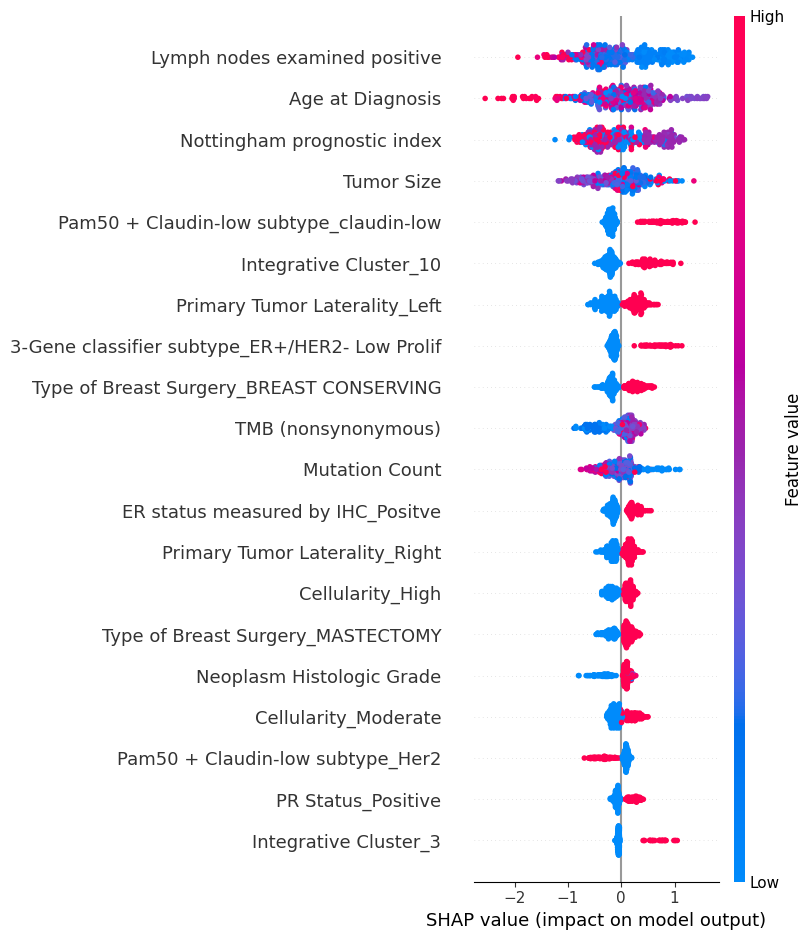

📌 SHAP Summary Bar Plot


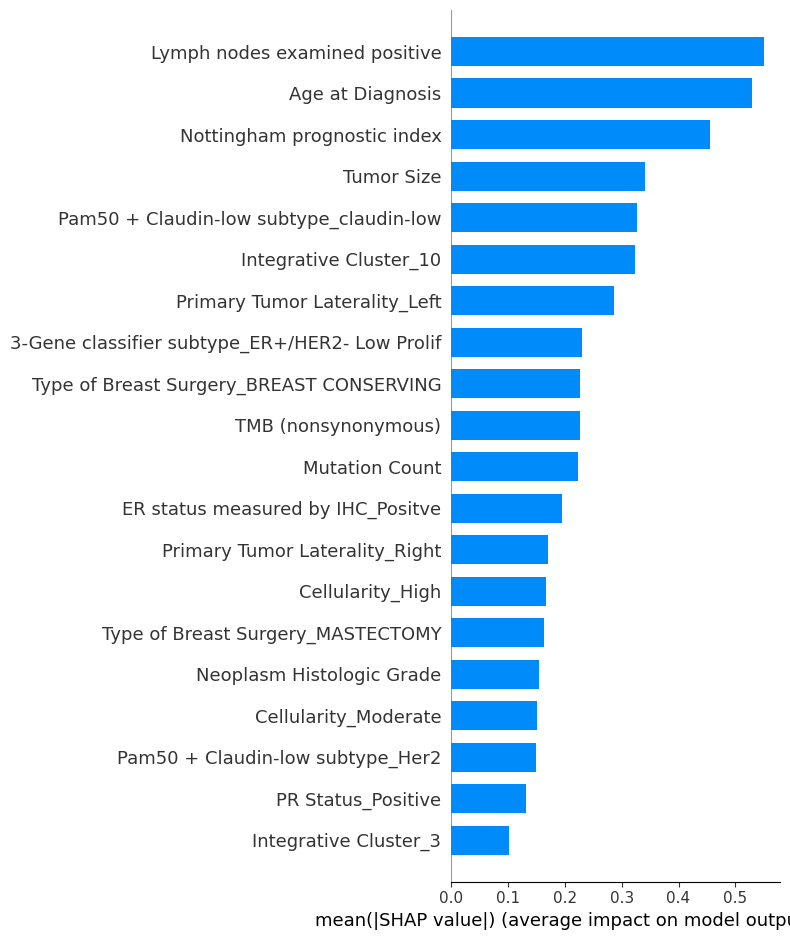

📌 Top SHAP Features (Global Importance)


,feature,importance
4,Lymph nodes examined positive,0.550895
0,Age at Diagnosis,0.529988
5,Nottingham prognostic index,0.456007
1,Tumor Size,0.340784
23,Pam50 + Claudin-low subtype_claudin-low,0.327718
40,Integrative Cluster_10,0.324118
50,Primary Tumor Laterality_Left,0.286954
59,3-Gene classifier subtype_ER+/HER2- Low Prolif,0.230406
8,Type of Breast Surgery_BREAST CONSERVING,0.227062
7,TMB (nonsynonymous),0.226537



📌 SHAP Dependence Plots (Top 2–3 Features)
Dependence plot for: Lymph nodes examined positive


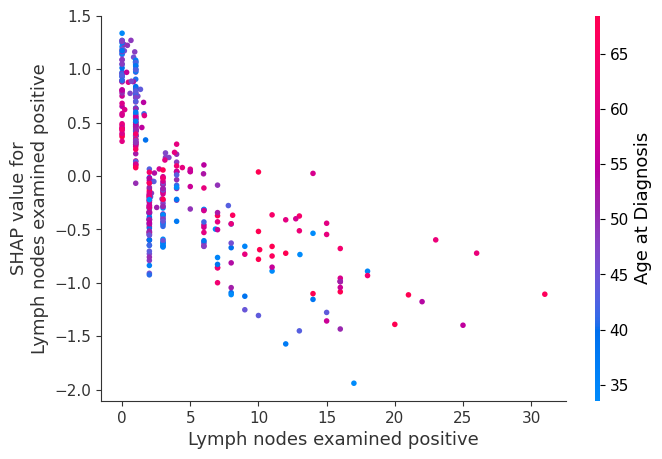

Dependence plot for: Age at Diagnosis


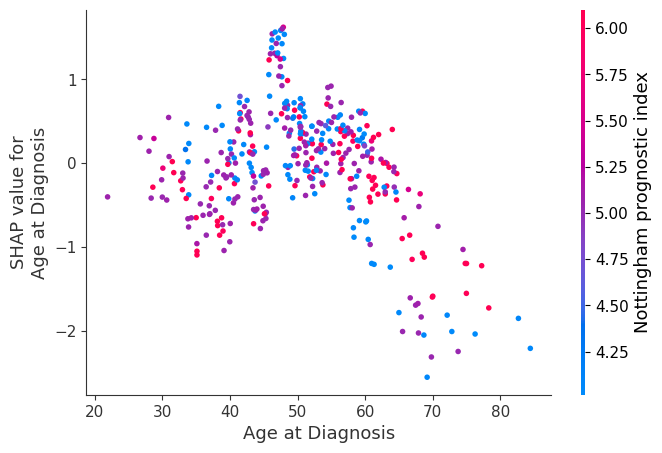

Dependence plot for: Nottingham prognostic index


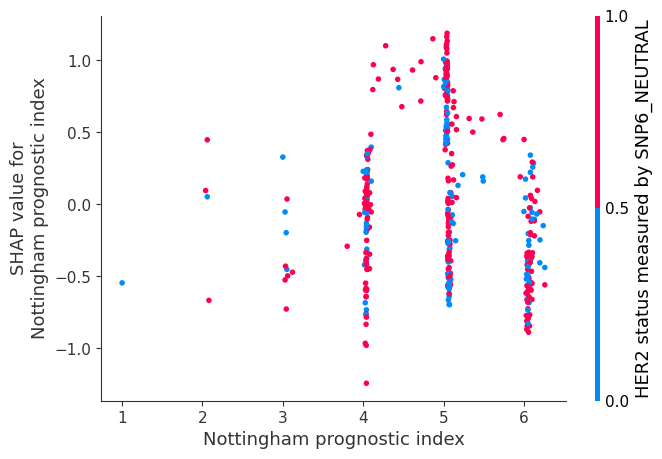


📌 SHAP Force Plot for sample index: 10



📌 Waterfall plot for sample index: 10


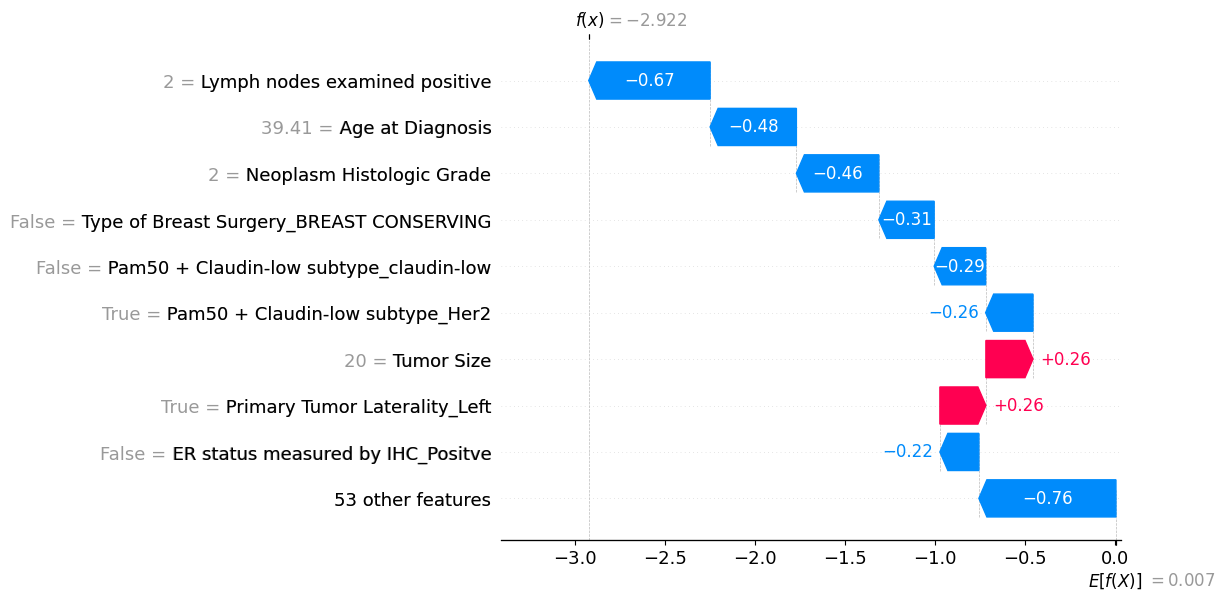


SHAP Explainability Completed.


In [100]:
explainer, shap_values, shap_ranking = full_shap_explainability(
    model=xgb,
    X_train=X_train_resampled,
    X_test=X_test,
    sample_index=10  # you can pick any test sample
)


In [101]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def full_shap_report(model, explainer, X_train, X_test, sample_index=0):
    """
    Generates a full SHAP explainability report:
      - Summary Dot Plot
      - Summary Bar Plot
      - Dependence Plots (Top 3 Features)
      - Ranking Table (Top 20)
      - Force Plot (1 sample)
      - Waterfall Plot (1 sample)
      - Text Summary (top + bottom SHAP features for sample)
    """

    print("\n==============================")
    print(" SHAP REPORT INITIALIZED")
    print("==============================\n")

    # -------------------------------------
    # Compute SHAP values
    # -------------------------------------
    print("Computing SHAP values...")
    shap_values = explainer.shap_values(X_train)
    print("SHAP values computed.\n")

    # -------------------------------------
    # GLOBAL SHAP SUMMARY DOT
    # -------------------------------------
    print("📌 GLOBAL SHAP SUMMARY (dot plot)")
    shap.summary_plot(shap_values, X_train, plot_type="dot")
    plt.show()

    # -------------------------------------
    # GLOBAL SHAP BAR PLOT
    # -------------------------------------
    print("📌 GLOBAL SHAP BAR PLOT")
    shap.summary_plot(shap_values, X_train, plot_type="bar")
    plt.show()

    # -------------------------------------
    # GLOBAL RANKING TABLE
    # -------------------------------------
    print("📌 TOP 20 GLOBAL SHAP FEATURES (numeric ranking)\n")
    global_importance = np.abs(shap_values).mean(axis=0)

    ranking_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": global_importance
    }).sort_values(by="importance", ascending=False)

    display(ranking_df.head(20))

    # -------------------------------------
    # DEPENDENCE PLOTS FOR TOP 3 FEATURES
    # -------------------------------------
    top3 = ranking_df["feature"].head(3).tolist()
    print("\n📌 SHAP DEPENDENCE PLOTS (top 3 features):\n", top3)

    for feat in top3:
        print(f"Dependence plot for feature: {feat}")
        shap.dependence_plot(feat, shap_values, X_train)
        plt.show()

    # -------------------------------------
    # LOCAL EXPLANATION — SINGLE PATIENT
    # -------------------------------------
    print(f"\n📌 LOCAL SHAP EXPLANATION FOR TEST SAMPLE INDEX: {sample_index}")
    shap.initjs()

    force_plot_obj = shap.force_plot(
        explainer.expected_value,
        explainer.shap_values(X_test.iloc[[sample_index]]),
        X_test.iloc[[sample_index]]
    )
    display(force_plot_obj)

    # WATERFALL PLOT
    print(f"\n📌 LOCAL WATERFALL PLOT FOR SAMPLE {sample_index}")
    local_shap_vals = explainer.shap_values(X_test.iloc[[sample_index]])[0]

    shap.plots.waterfall(
        shap.Explanation(
            values=local_shap_vals,
            base_values=explainer.expected_value,
            data=X_test.iloc[[sample_index]].iloc[0],
            feature_names=X_test.columns
        )
    )

    # -------------------------------------
    # TEXT SUMMARY — like your manual patient function
    # -------------------------------------
    local_df = pd.DataFrame({
        "feature": X_test.columns,
        "value": X_test.iloc[sample_index].values,
        "shap_value": local_shap_vals
    }).sort_values("shap_value", ascending=False)

    top_pos = local_df.head(5)
    top_neg = local_df.tail(5)

    text_summary = f"""
======================================
LOCAL EXPLANATION SUMMARY (Sample {sample_index})
======================================

TOP FEATURES INCREASING Prediction:
-----------------------------------
{top_pos[['feature','value','shap_value']].to_string(index=False)}

TOP FEATURES DECREASING Prediction:
-----------------------------------
{top_neg[['feature','value','shap_value']].to_string(index=False)}
"""

    print("\n📝 TEXT SUMMARY:")
    print(text_summary)

    return {
        "ranking_df": ranking_df,
        "top_positive": top_pos,
        "top_negative": top_neg,
        "text_summary": text_summary,
        "local_shap_values": local_shap_vals,
        "global_shap_values": shap_values
    }


In [102]:
def explain_manual_patient_summary(manual_values_dict, model, feature_cols, explainer):
    """
    Generates a clean SHAP-based text explanation for a single manual patient.
    NO PLOTS. Only textual summary + top factors.

    manual_values_dict : dict → {"Age at Diagnosis": 50, "Tumor Size": 22, ...}
    model              : trained model (xgb / rf)
    feature_cols       : list of encoded feature names
    explainer          : shap.TreeExplainer(model)
    """

    # --------------------------
    # Step 1 — Build one-hot row
    # --------------------------
    patient_df = pd.DataFrame(columns=feature_cols)
    patient_df.loc[0] = 0  # initialize everything to 0

    for key, val in manual_values_dict.items():
        if key in feature_cols:
            patient_df.loc[0, key] = val
        else:
            print(f"⚠️ Warning: Feature '{key}' not in model features.")

    # --------------------------
    # Step 2 — Predict
    # --------------------------
    pred = model.predict(patient_df)[0]
    prob = model.predict_proba(patient_df)[0][1]

    # --------------------------
    # Step 3 — SHAP values
    # --------------------------
    shap_vals = explainer.shap_values(patient_df)[0]

    shap_df = pd.DataFrame({
        "feature": feature_cols,
        "value": patient_df.loc[0].values,
        "shap_value": shap_vals
    }).sort_values("shap_value", ascending=False)

    top_positive = shap_df.head(5)
    top_negative = shap_df.tail(5)

    # --------------------------
    # Step 4 — Build TEXT REPORT
    # --------------------------
    text_report = f"""
======================================
CHEMOTHERAPY RESPONSE EXPLANATION
======================================

🔍 PATIENT PREDICTION
---------------------
Predicted Class: {pred}   (1 = Responder, 0 = Non-Responder)
Probability of Response: {prob:.3f}

📈 TOP FEATURES INCREASING Response Probability
-----------------------------------------------
{top_positive[['feature','value','shap_value']].to_string(index=False)}

📉 TOP FEATURES DECREASING Response Probability
-----------------------------------------------
{top_negative[['feature','value','shap_value']].to_string(index=False)}

"""

    return {
        "patient_df": patient_df,
        "prediction": pred,
        "probability": prob,
        "top_positive": top_positive,
        "top_negative": top_negative,
        "text_report": text_report
    }


In [103]:
result = explain_manual_patient_summary(
    manual_values_dict=manual_patient,
    model=best_model,
    feature_cols=feature_cols,
    explainer=explainer
)

print(result["text_report"])



CHEMOTHERAPY RESPONSE EXPLANATION

🔍 PATIENT PREDICTION
---------------------
Predicted Class: 1   (1 = Responder, 0 = Non-Responder)
Probability of Response: 0.588

📈 TOP FEATURES INCREASING Response Probability
-----------------------------------------------
                                  feature  value  shap_value
            Lymph nodes examined positive      0    1.015869
                           Mutation Count      0    0.420577
                               Tumor Size     22    0.420476
Tumor Other Histologic Subtype_Ductal/NST      0    0.141463
              Nottingham prognostic index      0    0.129179

📉 TOP FEATURES DECREASING Response Probability
-----------------------------------------------
                                       feature  value  shap_value
3-Gene classifier subtype_ER+/HER2- Low Prolif      0   -0.122518
       Pam50 + Claudin-low subtype_claudin-low      0   -0.131079
                 Primary Tumor Laterality_Left      0   -0.329509
            

In [105]:
! pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 70.1 MB/s eta 0:00:00


In [107]:
import streamlit as st
import joblib
import pandas as pd
import numpy as np
import shap

# --------------------------------------------------------
# Load Model & Feature Columns
# --------------------------------------------------------

st.title("🔬 Chemotherapy Response Predictor (METABRIC Clinical Model)")

st.write("""
This app predicts whether a breast cancer patient is likely to
**respond to chemotherapy**, using the METABRIC-trained machine learning model.
""")

# Load trained model
model = joblib.load("/content/drive/MyDrive/DES SEM III/HDS/HDS_Project/best_chemo_response_model.pkl")

# Load feature columns (IMPORTANT: must match training columns exactly)
# Option 1: Load from saved file
# feature_cols = pd.read_csv("feature_columns.csv")["features"].tolist()

# Option 2: Hardcode if needed
# feature_cols = [...]

# Using the feature_cols defined in the notebook context
feature_cols = X_train_resampled.columns

# SHAP explainer
explainer = shap.TreeExplainer(model)

# --------------------------------------------------------
# Sidebar Inputs
# --------------------------------------------------------
st.sidebar.header("🧍 Patient Clinical Inputs")

age = st.sidebar.slider("Age at Diagnosis", 20, 90, 50)
tumor_size = st.sidebar.slider("Tumor Size (mm)", 1, 200, 22)
tumor_stage = st.sidebar.selectbox("Tumor Stage", [1, 2, 3, 4])
grade = st.sidebar.selectbox("Histologic Grade", [1, 2, 3])

er_status = st.sidebar.selectbox("ER Status", ["Positive", "Negative"])
her2_status = st.sidebar.selectbox("HER2 Status", ["Positive", "Negative"])
pam50 = st.sidebar.selectbox("PAM50 Subtype",
    ["LumA", "LumB", "Her2", "Normal", "claudin-low"])

menopause = st.sidebar.selectbox("Menopausal State", ["Pre", "Post"])
oncotree = st.sidebar.selectbox("Oncotree Code", ["IDC", "ILC", "MBC", "MDLC", "IMMC"])

surgery = st.sidebar.selectbox(
    "Breast Surgery Type",
    ["MASTECTOMY", "BREAST CONSERVING"]
)

# --------------------------------------------------------
# Build manual input row
# --------------------------------------------------------

patient_df = pd.DataFrame(columns=feature_cols)
patient_df.loc[0] = 0  # initialize all features with 0

# Fill numeric values
patient_df.loc[0, "Age at Diagnosis"] = age
patient_df.loc[0, "Tumor Size"] = tumor_size
patient_df.loc[0, "Tumor Stage"] = tumor_stage
patient_df.loc[0, "Neoplasm Histologic Grade"] = grade

# One-hot encoded values
if er_status == "Positive":
    patient_df.loc[0, "ER Status_Positive"] = 1

if her2_status == "Positive":
    patient_df.loc[0, "HER2 Status_Positive"] = 1

if pam50 in ["LumA", "LumB", "Her2", "Normal", "claudin-low"]:
    colname = f"Pam50 + Claudin-low subtype_{pam50}"
    if colname in patient_df.columns:
        patient_df.loc[0, colname] = 1

if menopause == "Pre":
    patient_df.loc[0, "Inferred Menopausal State_Pre"] = 1

oncotree_col = f"Oncotree Code_{oncotree}"
if oncotree_col in patient_df.columns:
    patient_df.loc[0, oncotree_col] = 1

if surgery == "MASTECTOMY":
    patient_df.loc[0, "Type of Breast Surgery_MASTECTOMY"] = 1

# --------------------------------------------------------
# Prediction
# --------------------------------------------------------

st.subheader("🧮 Prediction")

prediction = model.predict(patient_df)[0]
prob = model.predict_proba(patient_df)[0][1]

if prediction == 1:
    st.success(f"**Responder** (Probability = {prob:.3f})")
else:
    st.error(f"**Non-Responder** (Probability = {prob:.3f})")

# --------------------------------------------------------
# SHAP Explainability
# --------------------------------------------------------

st.subheader("🧠 Model Explainability")

# For binary classification, shap_values is a list of two arrays (for class 0 and class 1)
# Each array is (1, num_features). We need to extract the 1D array for class 1.
shap_values = explainer.shap_values(patient_df)

# Show SHAP values text
top_features = pd.DataFrame({
    "Feature": patient_df.columns,
    "Value": patient_df.iloc[0],
    "SHAP": shap_values[0][:, 1] # Access SHAP values for the first sample (index 0) and class 1 (index 1)
}).sort_values(by="SHAP", ascending=False)

st.write("### 🔝 Top Factors Increasing Response")
st.dataframe(top_features.head(5))

st.write("### 🔻 Top Factors Decreasing Response")
st.dataframe(top_features.tail(5))

# SHAP Force Plot
st.write("### SHAP Force Plot")
shap.initjs()
force_html = shap.force_plot(
    explainer.expected_value[1], # Use expected value for class 1
    shap_values[0][:, 1],        # Use SHAP values for the first sample (index 0) and class 1 (index 1)
    patient_df,
    matplotlib=False
)

# Render HTML
st.components.v1.html(shap.getjs() + force_html.html(), height=300)

st.write("### 🚀 Explanation Complete")

2025-11-26 05:42:42.210 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:42.213 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:42.214 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:42.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:42.222 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:42.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:42.450 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:42.454 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2025-11-26 05:42:43.026 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:43.033 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:43.035 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:43.046 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:43.052 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-26 05:42:43.060 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
